# Inference: from frames to tracked players on the pitch

The inference modules turn match video into data:

1. **Models** (`tv.models`) detect people and the ball, and find pitch landmarks.
2. **Trackers** (`tv.tracking`) give each person an id that lasts across frames.
3. **Pitch geometry** (`tv.pitch`) maps frame pixels to pitch metres.
4. **Teams** (`tv.teams`) split players into teams by kit, without labels.
5. **The pipeline** (`tv.pipeline`) chains all of it over a video and returns a
   `PipelineResult` with tables, StatsBomb-style freeze frames and files.

Each part works on its own; the pipeline only connects them. The models are
the trained checkpoints in `models/` (see
[03_training_and_evaluation](03_training_and_evaluation.ipynb)).

Part of the [TactiFoot Vision notebooks](README.md).

In [1]:
import importlib.util
import json
import os
import warnings
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import supervision as sv

import tactifoot_vision as tv

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "04_inference"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

video = tv.VideoReader(VIDEO)
frame = video.read(250)

## Single-image predictions

A model is a callable: give it a BGR frame. Detectors return `sv.Detections`
with the class names in `data["class_name"]`, whatever the backend, so YOLO
and RF-DETR are interchangeable. Supervision's annotators draw them directly.

Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


yolo    22 objects {'player': 22}
rfdetr  22 objects {'player': 22}


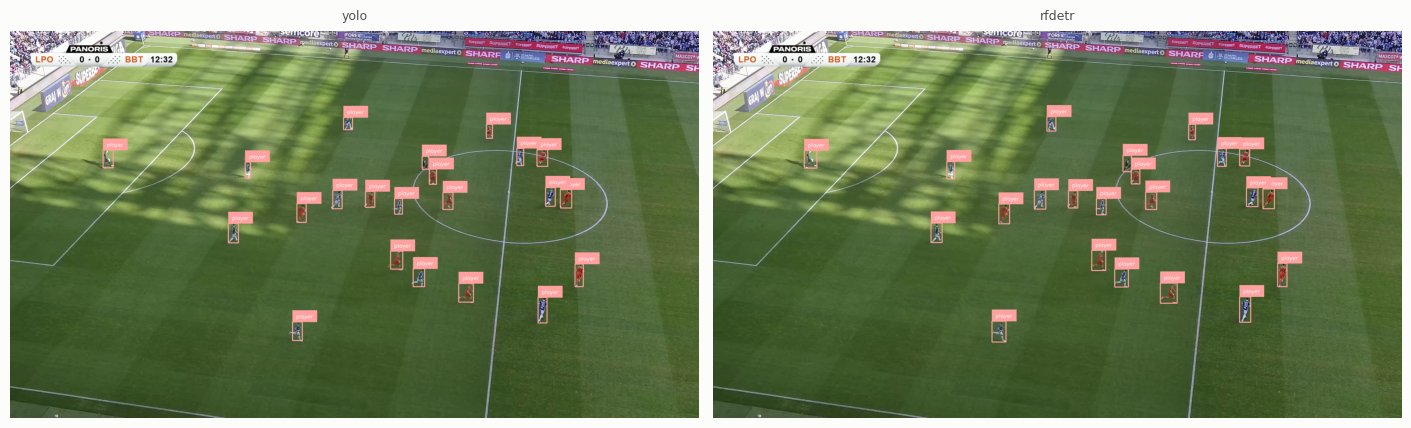

In [2]:
detectors = {
    "yolo": tv.load_model("yolo", MODELS / "football_yolo11m.pt", conf=0.3),
    "rfdetr": tv.load_model("rfdetr", MODELS / "football_rfdetr_base.pth", conf=0.5),
}
pitch_model = tv.load_model("yolo_pose", MODELS / "pitch_yolov8n_pose.pt")

views = []
for name, model in detectors.items():
    detections = model(frame)
    print(
        f"{name:7s} {len(detections):2d} objects",
        dict(Counter(detections.data["class_name"].tolist())),
    )
    view = sv.BoxAnnotator(thickness=2).annotate(frame.copy(), detections)
    views.append(
        sv.LabelAnnotator(text_scale=0.5).annotate(
            view, detections, labels=list(detections.data["class_name"])
        )
    )
tv.show(views, titles=list(detectors), cols=2, width=14)

The pose model returns `sv.KeyPoints`: for each detected pitch, 32 landmark
positions with a confidence each, in the order of `tv.SoccerPitch`'s vertices.

xy: (1, 32, 2)  confidence: (1, 32)
confident landmarks: [0, 1, 6, 8, 9, 10, 11, 13, 14, 15, 16, 30, 31]


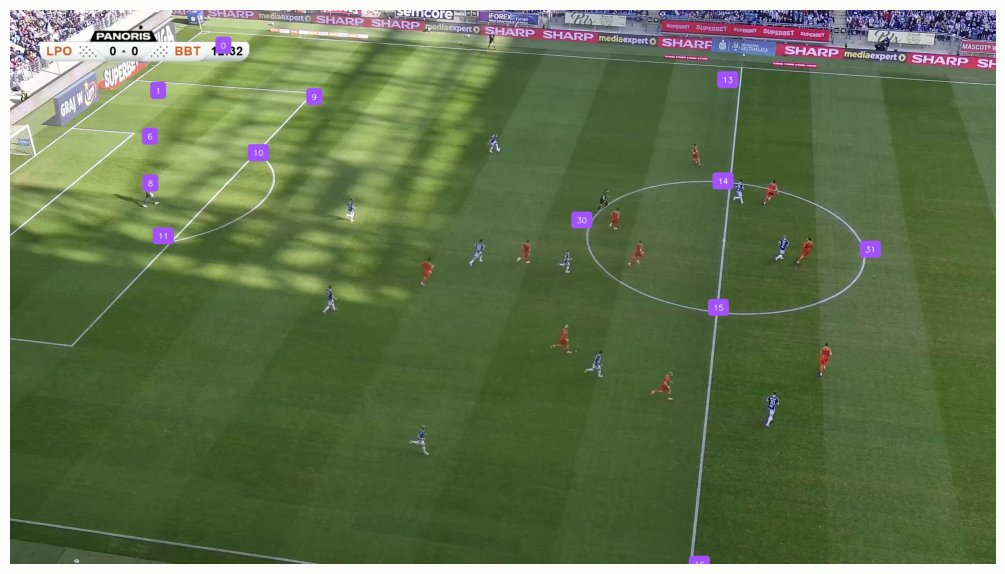

In [3]:
keypoints = pitch_model(frame)
print("xy:", keypoints.xy.shape, " confidence:", keypoints.confidence.shape)
confident = keypoints.confidence[0] > 0.5
print("confident landmarks:", np.flatnonzero(confident).tolist())
labelled = sv.VertexLabelAnnotator(text_scale=0.5, border_radius=4).annotate(
    frame.copy(),
    sv.KeyPoints(xy=keypoints.xy[:, confident]),
    labels=[str(i) for i in np.flatnonzero(confident)],
)
tv.show(labelled, width=10)

## Pitch geometry

`SoccerPitch` describes the pitch: 32 landmarks in pitch units, with the origin
in a corner, `x` along the length and `y` across. The default is 105 × 68 m;
`SoccerPitch(120, 80)` gives StatsBomb units with the same proportions.

SoccerPitch(length=105.0, width=68.0) | SoccerPitch(length=120, width=80)


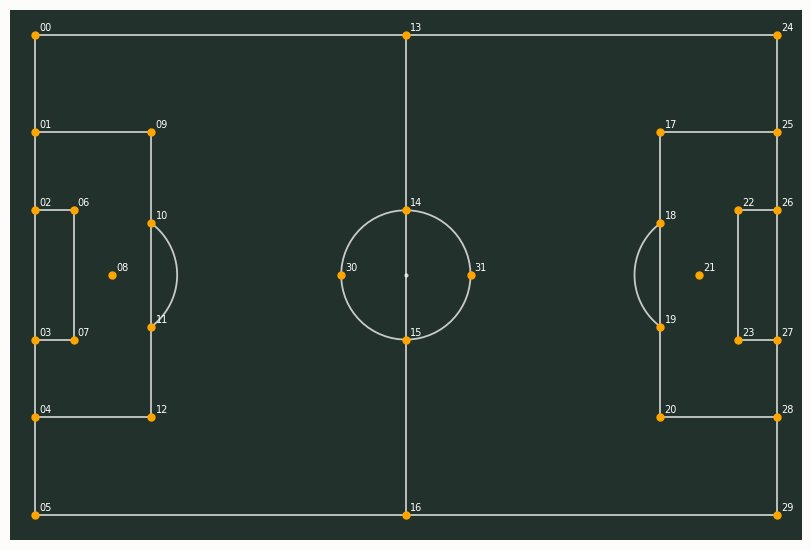

In [4]:
pitch = tv.SoccerPitch()
print(pitch, "|", tv.SoccerPitch(120, 80))
fig = tv.viz.draw_pitch(pitch=pitch, size=8)
ax = fig.axes[0]
ax.scatter(*pitch.vertices.T, s=25, color="#FFA500", zorder=3)
for label, (x, y) in zip(pitch.labels, pitch.vertices, strict=True):
    ax.annotate(
        label,
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7,
        color="white",
    )
fig

`HomographyEstimator.update(keypoints)` fits a frame → pitch homography from
the confident landmarks (RANSAC) and averages the last few fits to steady it
over time. `frame_to_pitch` then maps pixels to metres; here the players' feet,
the bottom centre of their boxes.

In [5]:
estimator = tv.pitch.HomographyEstimator(pitch)
homography = estimator.update(keypoints)
detections = detectors["yolo"](frame)
feet = detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
on_pitch = tv.pitch.frame_to_pitch(feet, homography)
print("landmarks used for the fit:", estimator.used_indices.tolist())
pd.DataFrame(on_pitch, columns=["x (m)", "y (m)"]).assign(
    class_name=detections.data["class_name"]
).head().round(1)

landmarks used for the fit: [0, 1, 6, 8, 9, 10, 11, 13, 14, 15, 16, 30, 31]


,x (m),y (m),class_name
0,46.700001,53.200001,player
1,34.400002,22.600000,player
2,45.599998,34.799999,player
3,53.799999,28.500000,player
4,50.299999,21.799999,player


`pitch_to_frame` goes the other way. Projecting all 32 landmarks back into the
frame shows how well the homography fits: the projected points (white) should
sit on the detected ones (orange), and landmarks outside the view land outside
the image.

reprojection error on the fitted landmarks: median 12.7 px


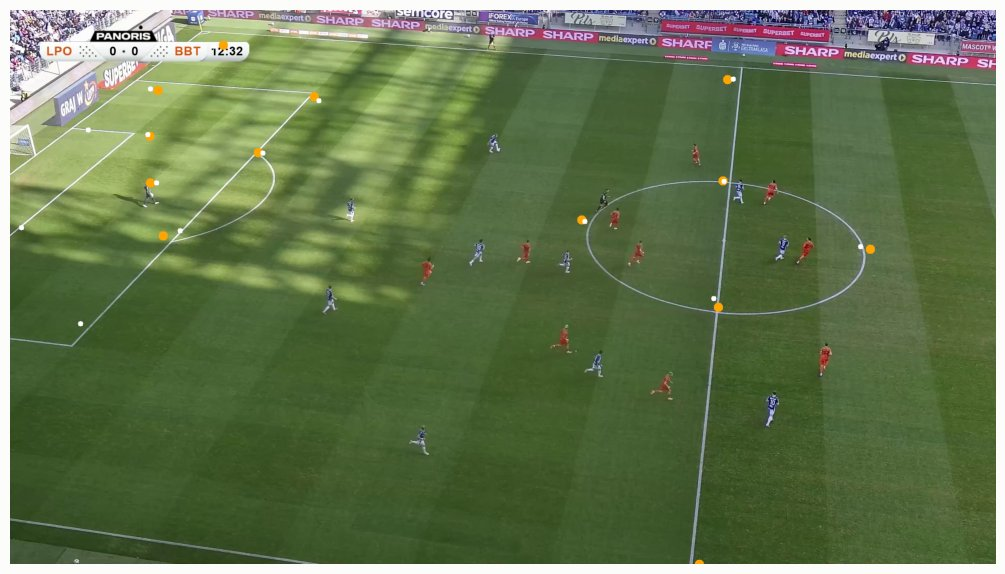

In [6]:
projected = tv.pitch.pitch_to_frame(pitch.vertices, homography)
used = estimator.used_indices
error = np.linalg.norm(projected[used] - keypoints.xy[0][used], axis=1)
print(f"reprojection error on the fitted landmarks: median {np.median(error):.1f} px")

check = frame.copy()
for x, y in keypoints.xy[0][used]:
    cv2.circle(check, (int(x), int(y)), 9, (0, 165, 255), -1)
for x, y in projected:
    if 0 <= x < video.width and 0 <= y < video.height:
        cv2.circle(check, (int(x), int(y)), 5, (255, 255, 255), -1)
tv.show(check, width=10)

## Trackers

A tracker gives each person a `tracker_id` that stays the same from frame to
frame. Trackers are created by name with `create_tracker`; all of them have
`reset(fps)` and `update(detections, frame)`.

In [7]:
print("available:", tv.tracking.available_trackers())
tracker = tv.tracking.create_tracker("bytetrack", lost_track_buffer=30)
tracker.reset(fps=video.fps)
ids_per_frame = []
for _, image in video.frames(start=250, end=300):
    people = detectors["yolo"](image)
    people = people[people.data["class_name"] != "ball"]
    tracked = tracker.update(people, image)
    ids_per_frame.append(set(tracked.tracker_id.tolist()))
stable = set.intersection(*ids_per_frame)
print(
    f"{len(set.union(*ids_per_frame))} ids over 50 frames; {len(stable)} present in every frame"
)

available: ['bytetrack', 'sam2']


23 ids over 50 frames; 12 present in every frame


ByteTrack matches boxes only and is fast. SAM2 tracks segmentation masks,
which holds identities better through overlaps, and is re-seeded from the
detector when new people enter. It needs the `sam2` extra and the SAM2
repository in `external/`; without them the next cell explains how to enable
it and the SAM2 parts of this notebook are skipped.

In [8]:
SAM2_REPO = ROOT / "external" / "segment-anything-2-real-time"
sam2_ready = SAM2_REPO.is_dir() and importlib.util.find_spec("hydra") is not None
if sam2_ready:
    # The checkout's optional compiled extension may not match the installed torch;
    # SAM2 then warns and uses its Python fallback, which is fine here.
    warnings.filterwarnings(
        "ignore", message="Falling back to the Python connected-components"
    )
    sam2_tracker = tv.tracking.create_tracker(
        "sam2",
        checkpoint=SAM2_REPO / "checkpoints" / "sam2.1_hiera_tiny.pt",
        config=SAM2_REPO / "sam2" / "configs" / "sam2.1" / "sam2.1_hiera_t.yaml",
    )
    print("SAM2 tracker ready:", type(sam2_tracker).__name__)
else:
    sam2_tracker = None
    print(
        "SAM2 is not available. To enable it:\n"
        "  git clone https://github.com/Gy920/segment-anything-2-real-time external/segment-anything-2-real-time\n"
        "  (download its checkpoints with checkpoints/download_ckpts.sh)\n"
        "  uv sync --extra sam2"
    )

SAM2 tracker ready: SAM2Tracker


## Team classification

Teams are found without labels. `extract_crops` cuts the central part of each
player box (shirt and shorts, little grass); an embedder turns each crop into a
feature vector; `TeamClassifier` reduces them with UMAP and clusters them into
two teams. Referees and goalkeepers are handled by the pipeline later.

In [9]:
crops = []
for _, image in video.frames(start=0, end=500, stride=50):
    people = detectors["yolo"](image)
    players = people[people.data["class_name"] == "player"]
    crops += [
        crop
        for crop in tv.teams.extract_crops(image, players.xyxy, scale=0.8)
        if crop is not None
    ]
print(len(crops), "player crops; embedders:", tv.teams.available_embedders())

212 player crops; embedders: ['resnet', 'siglip']


TeamClassifier(embedder=SigLIPEmbedder, n_teams=2, reducer='umap', fitted=True) | team sizes: [112, 100]


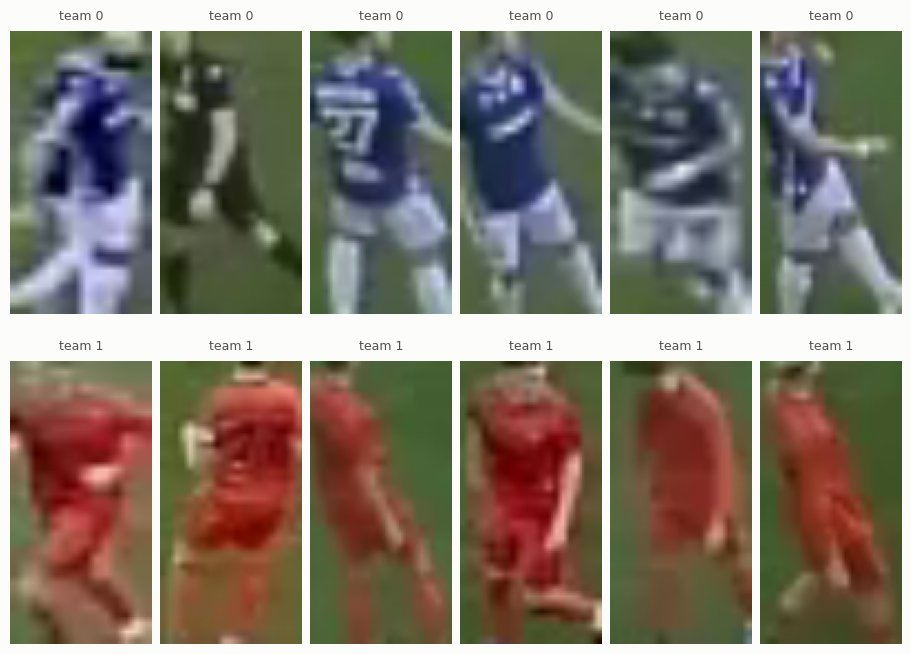

In [10]:
classifier = tv.teams.TeamClassifier(embedder="siglip")
teams = classifier.fit_predict(crops)
print(classifier, "| team sizes:", np.bincount(teams).tolist())

examples = [crops[i] for team in (0, 1) for i in np.flatnonzero(teams == team)[:6]]
tv.show(
    [cv2.resize(c, (64, 128)) for c in examples],
    titles=[f"team {t}" for t in (0, 1) for _ in range(6)],
    cols=6,
    width=9,
)

The embedder is swappable. ResNet-18 features are cheaper than SigLIP; team
numbers are arbitrary, so agreement is measured up to swapping 0 and 1.

In [11]:
resnet_teams = tv.teams.TeamClassifier(embedder="resnet").fit_predict(crops)
agreement = max(np.mean(resnet_teams == teams), np.mean(resnet_teams != teams))
print(f"ResNet and SigLIP agree on {agreement:.0%} of the crops")

ResNet and SigLIP agree on 100% of the crops


## The full pipeline

`tv.Pipeline` chains everything per frame: detect, split off the ball, track
the people, fit the homography and project everyone onto the pitch. After the
pass each track gets one team by majority vote over its crops, goalkeepers join
the team whose players are nearest, and ball positions that jump implausibly
far are dropped. Every part is an object you pass in; a tracker can also be
given by name.

In [12]:
pipeline = tv.Pipeline(
    detector=detectors["yolo"],
    keypoint_model=pitch_model,
    tracker="bytetrack",
    team_classifier=tv.teams.TeamClassifier(embedder="siglip"),
)
result = pipeline.run(VIDEO, max_frames=375, progress=False)  # the first 15 seconds
print(len(result), "frames,", len(result.track_ids), "tracks,", f"{result.fps:.0f} fps")

375 frames, 41 tracks, 25 fps


A `PipelineResult` is a list of `FrameResult`s. Each holds the tracked people
and the ball as `sv.Detections` with `pitch_xy` and `team_id` attached, the
pitch keypoints and the homography.

In [13]:
frame_result = result[100]
print("frame", frame_result.index, f"at {frame_result.timestamp:.2f} s")
print("people:", len(frame_result.detections), "ball:", len(frame_result.ball))
print("teams:", Counter(frame_result.team_ids.tolist()), "(-1 = no team: referees)")
print(
    "homography:",
    None if frame_result.homography is None else frame_result.homography.shape,
)

frame 100 at 4.00 s
people: 20 ball: 0
teams: Counter({0: 12, 1: 8}) (-1 = no team: referees)
homography: (3, 3)


Because teams are voted per track, every frame of a track carries the same
team. The table counts tracks per class and team.

In [14]:
tracks = result.to_dataframe()
people = tracks[tracks["object"] == "person"]
print(
    "tracks with more than one team:",
    int((people.groupby("track_id")["team_id"].nunique() > 1).sum()),
)
people.groupby(["class_name", "team_id"])["track_id"].nunique().unstack(fill_value=0)

tracks with more than one team: 0


team_id,0,1
class_name,,
player,23,18


### Tables, freeze frames and the run folder

`to_dataframe` gives one row per object per frame. `to_freeze_frames` gives the
StatsBomb 360 shape: one row per object with match-clock time, JSON-encoded
pitch location and the visible area of the pitch. `period_start` is the match
clock at the first frame, in seconds.

In [15]:
tracks.head()

,frame,time,object,track_id,class_name,team_id,confidence,x1,y1,x2,y2,pitch_x,pitch_y
0,0,0.0,person,1,player,0,0.837402,1167.532104,262.105591,1181.763672,306.801544,65.860695,36.484665
1,0,0.0,person,2,player,0,0.820818,507.820129,362.145264,531.683899,411.203613,43.517876,41.029610
2,0,0.0,person,3,player,0,0.819549,356.377350,564.270386,381.926788,618.030518,40.897167,52.556580
3,0,0.0,person,4,player,1,0.816118,1327.150391,288.900574,1344.192505,333.207520,70.983147,39.493446
4,0,0.0,person,5,player,1,0.812810,1322.293579,519.817566,1347.726807,571.203003,67.074409,54.236786


In [16]:
freeze_frames = result.to_freeze_frames(period=1, period_start=17 * 60 + 15)
freeze_frames[
    [
        "frame_id",
        "period",
        "timestamp",
        "minute",
        "second",
        "player_id",
        "type",
        "team_id",
        "location",
    ]
].head()

,frame_id,period,timestamp,minute,second,player_id,type,team_id,location
0,0,1,00:17:15.000,17,15,1,player,0,"[65.8606948852539, 36.48466491699219]"
1,0,1,00:17:15.000,17,15,2,player,0,"[43.51787567138672, 41.02960968017578]"
2,0,1,00:17:15.000,17,15,3,player,0,"[40.89716720581055, 52.55657958984375]"
3,0,1,00:17:15.000,17,15,4,player,1,"[70.98314666748047, 39.493446350097656]"
4,0,1,00:17:15.000,17,15,5,player,1,"[67.07440948486328, 54.236785888671875]"


`export` writes the run folder, the same files `tactifoot run` writes:
`result.pkl`, `tracks.csv` and `freeze_frames.csv`. `save` and
`PipelineResult.load` keep the whole result for later, for example to render
it again with other settings (see [05_visualisation](05_visualisation.ipynb)).

In [17]:
run_folder = result.export(OUT / "run", period=1, period_start=17 * 60 + 15)
print(sorted(p.name for p in run_folder.iterdir()))

saved = result.save(OUT / "result.pkl")
loaded = tv.PipelineResult.load(saved)
print(
    "reloaded:",
    len(loaded),
    "frames; same tables:",
    loaded.to_dataframe().equals(tracks),
)

['freeze_frames.csv', 'result.pkl', 'tracks.csv']
reloaded: 375 frames; same tables: True


### Swapping components

Components are plain objects, so changing one is a change of argument. Here
RF-DETR replaces YOLO and there is no team classifier.

In [18]:
rfdetr_result = tv.Pipeline(
    detector=detectors["rfdetr"], keypoint_model=pitch_model
).run(VIDEO, max_frames=125, progress=False)
print(len(rfdetr_result), "frames,", len(rfdetr_result.track_ids), "tracks")

125 frames, 25 tracks


With SAM2 as the tracker, `keep_masks=True` keeps each person's mask in
`FrameResult.masks`, cropped to the pixels it covers so memory grows with the
people's area, not the frame's. `FrameAnnotator(draw_masks=True)` draws them.

60 frames, 24 tracks; 23 masks in the last frame, 34 kB


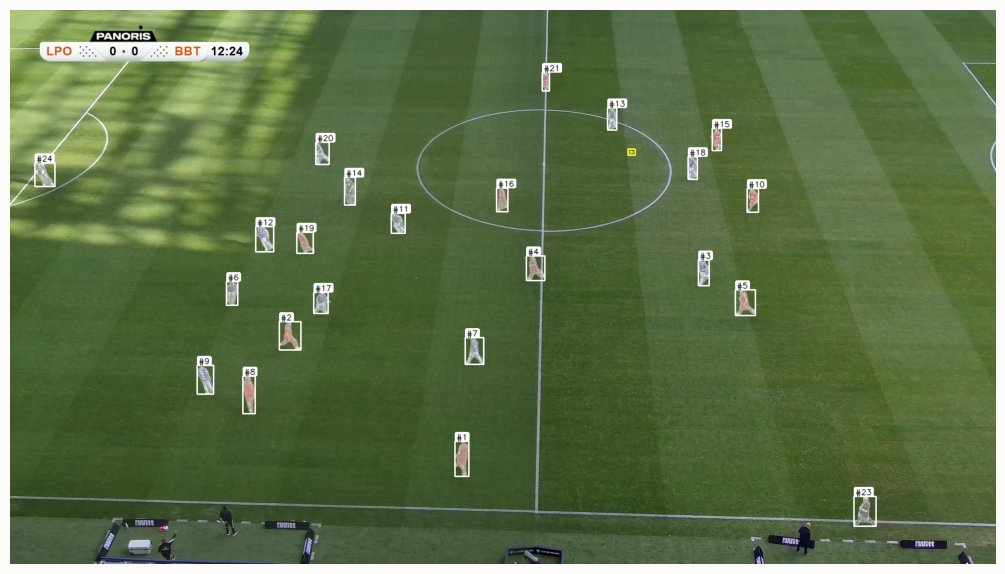

In [19]:
if sam2_tracker is None:
    print("Skipped: SAM2 is not available (see the Trackers section).")
else:
    masked = tv.Pipeline(
        detector=detectors["rfdetr"],
        keypoint_model=pitch_model,
        tracker=sam2_tracker,
        keep_masks=True,
    ).run(VIDEO, max_frames=60, progress=False)
    masks = masked[-1].masks
    print(
        len(masked),
        "frames,",
        len(masked.track_ids),
        "tracks;",
        f"{len(masks)} masks in the last frame, {sum(c.size for c in masks.crops) / 1e3:.0f} kB",
    )
    annotator = tv.viz.FrameAnnotator(
        draw_masks=True, draw_pitch_lines=False, draw_keypoints=False
    )
    display(
        tv.show(annotator.annotate(video.read(masked[-1].index), masked[-1]), width=10)
    )

## Comparing with StatsBomb 360

`compare_with_statsbomb(freeze_frames, statsbomb, period)` matches every
StatsBomb object to the nearest detected object in the same match second and
reports the distance. Both sides must use the same pitch units, so the
pipeline is built with `pitch=tv.SoccerPitch(120, 80)`, and the video must
show the match the events describe:

```python
pipeline = tv.Pipeline(..., pitch=tv.SoccerPitch(120, 80))
result = pipeline.run(match_video)
comparison = tv.evaluation.compare_with_statsbomb(
    result.to_freeze_frames(period=1, period_start=kickoff_offset_seconds), statsbomb, period=1)
```

The local StatsBomb data (`data/statsbomb/`) is Lech Poznań vs Zagłębie Lubin,
while the local video is from a different match, so a real comparison is not
possible here. The cell below shows what the function returns using a
stand-in for the detections: StatsBomb's own positions, moved by about one
unit of noise. A perfect detector would score exactly that noise.

In [20]:
statsbomb = tv.data.load_statsbomb(DATA / "statsbomb")
reference = statsbomb[(statsbomb["period"] == 1) & (statsbomb["minute"] == 20)]
rng = np.random.default_rng(0)
stand_in = reference[["period", "minute", "second", "type"]].assign(
    location=[
        json.dumps((np.asarray(xy) + rng.normal(0, 1, 2)).tolist())
        for xy in reference["pitch_location"]
    ],
)
comparison = tv.evaluation.compare_with_statsbomb(stand_in, statsbomb, period=1)
matched = comparison.dropna(subset=["euclidean_distance"])
print(
    f"{len(matched)} StatsBomb objects matched; median distance {matched['euclidean_distance'].median():.2f} units"
)
matched[
    [
        "minute",
        "second",
        "type",
        "pitch_location",
        "detected_location",
        "euclidean_distance",
    ]
].head()

946 StatsBomb objects matched; median distance 0.94 units


,minute,second,type,pitch_location,detected_location,euclidean_distance
491,20,56,player,"[63.4431836465664, 32.773151168765544]","[63.568913867659795, 32.64104630547424]",0.182373
492,20,56,player,"[72.73611468774048, 51.234175996229226]","[73.37653733818377, 51.33907611338226]",0.648957
493,20,56,player,"[76.76534958502762, 34.015957719146826]","[76.22968021186651, 34.37755277405631]",0.646291
494,20,56,player,"[71.4000015258789, 60.099998474121094]","[72.7639109103807, 60.64630423958539]",1.469251
495,20,56,player,"[70.14166813801911, 69.07249182161593]","[71.11819523537176, 68.71720058762894]",1.039152


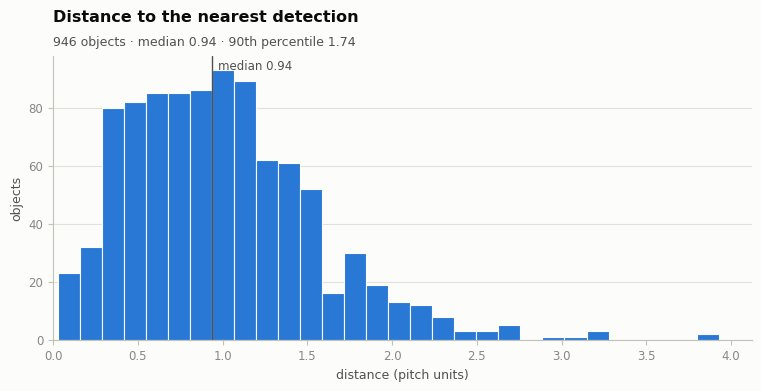

In [21]:
tv.viz.plot_distance_histogram(matched["euclidean_distance"], bins=30)